In [24]:
import pandas as pd
import sys                          
import numpy as np             # Data manipulation 
from sklearn.decomposition import PCA        # The main algorithm
from matplotlib import pyplot as plt         # Graphing
import seaborn as sns                        # Graphing
from collections import defaultdict, Counter # Utils
sns.set(style="white")                       # Tuning the style of charts
import warnings                              # Disable some warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

In [58]:
data_factorySolarGen = pd.read_csv('Generacion_fotovoltaica.csv')
data_gridInput = pd.read_csv('Consumo.csv')
data_Weather = pd.read_csv('Meteorologia.csv')
data_CarbonIntensity23 = pd.read_csv('ES_2023_hourly.csv')
data_CarbonIntensity24 = pd.read_csv('ES_2024_hourly.csv')
data_CarbonIntensity = pd.concat([data_CarbonIntensity23, data_CarbonIntensity24], ignore_index=True)
data_factorySolarUse = pd.read_csv('Consumo_fotovoltaica.csv')

data_CDM2023 = pd.read_csv('ComunidadData/2023.csv',delimiter=';')
data_CDM2023 = data_CDM2023.drop(columns=data_CDM2023.filter(regex=r'^v\d{2}$').columns)
data_CDM2023 = data_CDM2023.drop(columns=['punto_muestreo'])

data_CDM2023 = data_CDM2023[data_CDM2023['']]

,provincia,municipio,estacion,magnitud,ano,mes,dia,h01,h02,h03,...,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24
0,28,102,1,81,2023,1,1,"1,7","1,3","1,6",...,"3,3","2,8",3,"3,4",3,"2,7","2,4","2,5",3,"2,9"
1,28,102,1,82,2023,1,1,173,138,136,...,171,164,159,97,127,173,184,184,127,156
2,28,102,1,83,2023,1,1,"7,5","7,1","6,9",...,"14,2","14,2","13,4","12,9","11,6","10,7","11,1",11,"11,2","10,3"
3,28,102,1,86,2023,1,1,50,51,50,...,35,33,33,34,38,40,37,38,37,41
4,28,102,1,87,2023,1,1,932,932,932,...,928,928,928,928,928,928,928,928,928,929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68908,28,92,5,83,2023,12,31,"4,1",4,"4,8",...,"8,2","7,7","6,9","6,2","5,9","5,5",5,"4,9","4,8","4,6"
68909,28,92,5,86,2023,12,31,89,90,93,...,80,84,93,99,100,100,100,100,100,99
68910,28,92,5,87,2023,12,31,943,942,942,...,941,941,942,942,943,943,943,943,943,944
68911,28,92,5,88,2023,12,31,0,0,0,...,206,53,2,0,0,0,0,0,0,0


In [26]:
def renameAndIndex(df,datetime):
    df=df.rename(columns={datetime:'TIMESTAMP'})
    df['TIMESTAMP']=pd.to_datetime(df['TIMESTAMP'])
    df.set_index('TIMESTAMP', inplace=True)
    return df

In [27]:
data_factorySolarGen = renameAndIndex(data_factorySolarGen,'FECHA')
data_gridInput = renameAndIndex(data_gridInput,'FECHA')
data_Weather = renameAndIndex(data_Weather,'FORECAST_TIMESTAMP')
data_CarbonIntensity = renameAndIndex(data_CarbonIntensity,'Datetime (UTC)')
data_factorySolarUse = renameAndIndex(data_factorySolarUse,'FECHA')

In [28]:
allDatasets = {
    "factorySolarGen": data_factorySolarGen,
    "gridInput": data_gridInput,
    "weather": data_Weather,
    "carbonIntensity": data_CarbonIntensity,
    "factorySolarUse": data_factorySolarUse
}

minMaxDates = {}
for name, dataset in allDatasets.items():
    min_date = dataset.index.min()
    max_date = dataset.index.max()
    dataLen = len(dataset)
    minMaxDates[name] = {"min": min_date, "max": max_date, "rows":dataLen}

timeframes = pd.DataFrame(minMaxDates)

timeframes


,factorySolarGen,gridInput,weather,carbonIntensity,factorySolarUse
min,2023-07-24 11:00:00,2023-07-24 11:00:00,2023-07-24 11:00:00+00:00,2023-01-01 00:00:00,2024-09-01 00:00:00+02:00
max,2024-08-31 23:00:00,2024-08-31 23:00:00,2024-10-31 23:00:00+00:00,2024-12-31 23:00:00,2024-10-17 23:00:00+02:00
rows,9708,9708,100557,17544,1128


In [29]:
coords = data_Weather[['LATITUDE', 'LONGITUDE']].drop_duplicates().values.tolist()
coords

# Since the weather data is collected from 9 distinct points, according to the EDA, we can average these 9 points to get an accurate reading, as we don't know exact factory location

data_Weather.groupby('TIMESTAMP').mean()

coords

[[40.0, -4.0],
 [40.0, -3.75],
 [40.0, -3.5],
 [40.25, -4.0],
 [40.25, -3.75],
 [40.25, -3.5],
 [40.5, -4.0],
 [40.5, -3.75],
 [40.5, -3.5]]

In [30]:
from geopy.distance import geodesic  # accurate distance calculation

repsolPintoCoords = [40.265468,3.738145] # Solar installation location from GMaps

grid_coords = coords
target_coord = repsolPintoCoords

distances = [geodesic(coord, target_coord).kilometers for coord in grid_coords]

inv_distances = [1/d if d != 0 else 1e9 for d in distances]  # Avoid division by zero
total = sum(inv_distances)
weights = [w/total for w in inv_distances]

point_names = [f"point{i+1}" for i in range(len(grid_coords))]
weight_mapping = dict(zip(point_names, weights))

In [31]:
point_labels = [f"point{i+1}" for i in range(len(coords))]

coord_to_label = {tuple(coord): label for coord, label in zip(coords, point_labels)}

data_Weather['point'] = data_Weather[['LATITUDE', 'LONGITUDE']].apply(
    lambda row: coord_to_label.get((row['LATITUDE'], row['LONGITUDE']), None),
    axis=1
)

data_Weather['weight'] = data_Weather['point'].map(weight_mapping)

columns_to_weight = [col for col in data_Weather.columns if col not in ['LATITUDE', 'LONGITUDE','point']]

for col in columns_to_weight:
    data_Weather[col] = data_Weather[col] * data_Weather['weight']

data_Weather = data_Weather.drop(columns=['point','weight','LATITUDE','LONGITUDE'])

data_Weather = data_Weather.groupby('TIMESTAMP').sum()

data_Weather.index = data_Weather.index.tz_convert(None)

data_Weather

,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,dswrfsurface_0,gustsurface_0,...,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-07-24 11:00:00,5.1798,2.3060,17.5448,0.0046,301.8255,18000.0000,300.3335,320.6474,568.8246,6.8270,...,94006.0935,2.6812,299.1812,301.8450,293.3002,324.8847,0.0000,315.5007,5.9903,2.4358
2023-07-24 12:00:00,5.6693,2.5848,16.9633,0.0048,303.1875,21600.0000,301.3592,324.4215,634.5346,7.7205,...,93948.8741,3.7298,300.4113,303.2184,293.3002,325.7292,0.0000,317.4330,6.6514,2.7996
2023-07-24 13:00:00,6.2576,2.4652,17.0443,0.0052,304.3330,3600.0000,302.3031,352.2863,979.9382,8.5557,...,93885.1064,39.3103,301.5184,304.3268,303.2224,326.2833,0.0000,318.0650,7.4457,2.6937
2023-07-24 14:00:00,7.0069,2.0395,17.2424,0.0055,305.1067,7200.0000,302.9900,356.8543,956.2874,9.3402,...,93828.1926,22.9482,302.3685,305.1260,303.2224,327.1436,0.0000,317.4981,8.4133,2.2511
2023-07-24 15:00:00,7.4700,2.0502,17.3927,0.0057,305.5551,10800.0000,303.4017,360.4689,914.8154,9.6399,...,93770.0773,57.7714,303.0337,305.6194,303.2224,330.2707,0.0000,315.9591,8.9119,2.3292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-31 19:00:00,1.7002,-0.1165,73.1093,0.0083,288.4657,0.0000,288.4727,332.8403,0.0000,3.2826,...,94664.2236,41.7283,288.4546,289.3676,288.2639,295.1688,0.0137,287.8551,2.5258,0.1157
2024-10-31 20:00:00,1.1684,0.0624,75.1113,0.0084,288.0525,0.0000,288.0457,326.4712,0.0000,2.0167,...,94686.8964,54.3948,288.2198,289.4885,287.6420,295.5853,0.0137,287.2548,1.8365,0.2293
2024-10-31 21:00:00,0.8309,0.0995,74.7340,0.0083,288.0830,0.0000,288.0919,328.1211,0.0000,1.7123,...,94710.2685,70.7331,288.1488,289.5985,287.4000,295.1754,0.0137,287.2210,1.4041,0.2458


In [32]:
data_All = pd.concat([
    data_factorySolarGen.add_prefix("SG_"),
    data_gridInput.add_prefix("GI_"),
    data_Weather.add_prefix("W_")
], axis=1, join='inner')

In [33]:
data_All



,SG_TOTAL_KWH_ENERGIA,GI_TOTAL_KWH_ENERGIA,W_10uheightAboveGround_10,W_10vheightAboveGround_10,W_2rheightAboveGround_2,W_2shheightAboveGround_2,W_2theightAboveGround_2,W_SUNSDsurface_0,W_aptmpheightAboveGround_2,W_dlwrfsurface_0,...,W_spsurface_0,W_tccatmosphere_0,W_theightAboveGround_80,W_tmaxheightAboveGround_2,W_tminheightAboveGround_2,W_tozneatmosphereSingleLayer_0,W_tpsurface_0,W_tsurface_0,W_uheightAboveGround_80,W_vheightAboveGround_80
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-07-24 11:00:00,NaN,506.0126,5.1798,2.3060,17.5448,0.0046,301.8255,18000.0000,300.3335,320.6474,...,94006.0935,2.6812,299.1812,301.8450,293.3002,324.8847,0.0000,315.5007,5.9903,2.4358
2023-07-24 12:00:00,115.6600,456.5515,5.6693,2.5848,16.9633,0.0048,303.1875,21600.0000,301.3592,324.4215,...,93948.8741,3.7298,300.4113,303.2184,293.3002,325.7292,0.0000,317.4330,6.6514,2.7996
2023-07-24 13:00:00,129.9800,395.3186,6.2576,2.4652,17.0443,0.0052,304.3330,3600.0000,302.3031,352.2863,...,93885.1064,39.3103,301.5184,304.3268,303.2224,326.2833,0.0000,318.0650,7.4457,2.6937
2023-07-24 14:00:00,134.3500,330.0530,7.0069,2.0395,17.2424,0.0055,305.1067,7200.0000,302.9900,356.8543,...,93828.1926,22.9482,302.3685,305.1260,303.2224,327.1436,0.0000,317.4981,8.4133,2.2511
2023-07-24 15:00:00,133.9000,183.1466,7.4700,2.0502,17.3927,0.0057,305.5551,10800.0000,303.4017,360.4689,...,93770.0773,57.7714,303.0337,305.6194,303.2224,330.2707,0.0000,315.9591,8.9119,2.3292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31 19:00:00,NaN,51.1641,1.3097,0.9041,49.8420,0.0115,299.6837,2589.5064,299.8379,385.4733,...,94039.0978,15.2525,299.7749,301.0923,299.6460,303.3610,0.0282,298.7906,2.1563,1.2943
2024-08-31 20:00:00,NaN,46.2257,0.4040,0.7157,51.9343,0.0116,299.1719,2589.4846,299.2176,381.2723,...,94060.7527,95.5482,299.4553,301.0920,299.0919,304.1787,0.0497,298.1008,0.9590,1.0017
2024-08-31 21:00:00,NaN,81.4686,-0.3968,1.1221,53.0843,0.0117,298.8500,2589.5519,298.8473,380.1093,...,94078.3995,100.0000,299.1369,301.0920,298.8018,302.9903,0.0569,297.7637,-0.1415,1.5148


In [46]:
data_All.to_csv('cleaned_data.csv')

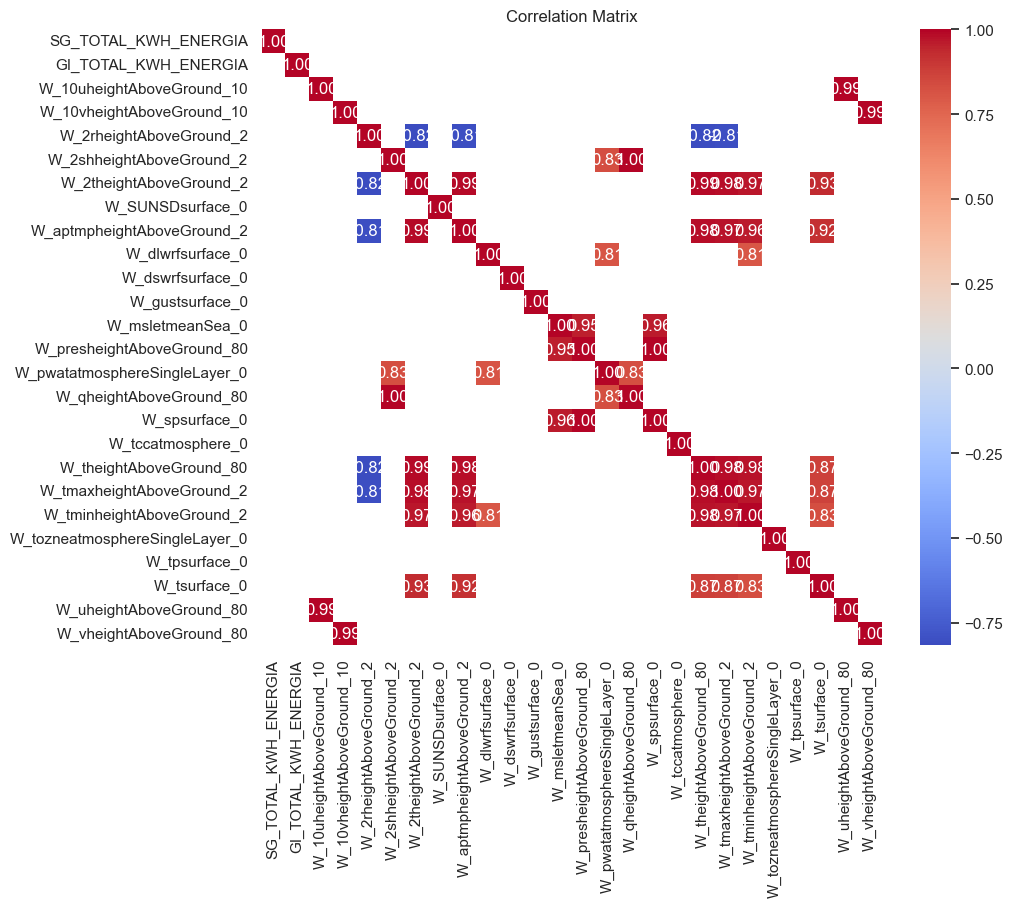

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = data_All.corr()
filtered_corr = correlation_matrix[correlation_matrix.abs() > 0.8]
plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
data_All.drop(columns=[])

## Principal Component Analysis

### Null Imputation

In [36]:
import numpy as np

numerical_columns = list(data_All.select_dtypes(include=[np.number]).columns)

impute = True # you can change this

if impute:
    # Use mean for numerical features
    for feature in data_All:
        v = data_All[feature].mean()
        if np.isnan(v):
            v = 0
        print("Filling %s with %s" % (feature, v))
        data_All[feature] = data_All[feature].fillna(v)

else:        
    # drop records
    data_All.dropna(inplace=True)

Filling SG_TOTAL_KWH_ENERGIA with 25.395278558052432
Filling GI_TOTAL_KWH_ENERGIA with 204.51042321475296
Filling W_10uheightAboveGround_10 with 1.3021894339378584
Filling W_10vheightAboveGround_10 with 0.4429861557820012
Filling W_2rheightAboveGround_2 with 50.57990573793787
Filling W_2shheightAboveGround_2 with 0.006208356537431647
Filling W_2theightAboveGround_2 with 290.94248247676086
Filling W_SUNSDsurface_0 with 6178.467455208005
Filling W_aptmpheightAboveGround_2 with 290.16934378306007
Filling W_dlwrfsurface_0 with 323.2102952167248
Filling W_dswrfsurface_0 with 210.42779214653933
Filling W_gustsurface_0 with 5.382198286131842
Filling W_msletmeanSea_0 with 101585.22085939063
Filling W_presheightAboveGround_80 with 93479.85078133739
Filling W_pwatatmosphereSingleLayer_0 with 16.569260924550722
Filling W_qheightAboveGround_80 with 0.006034839595974294
Filling W_spsurface_0 with 94357.31189350307
Filling W_tccatmosphere_0 with 44.55483082417675
Filling W_theightAboveGround_80 with

In [37]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler().fit(data_All)
X_std = ss.transform(data_All)

#### Compute PCA

In [38]:
sklearn_pca = PCA()
Y_sklearn = sklearn_pca.fit_transform(X_std)

#### Eigenvector Explained Variance

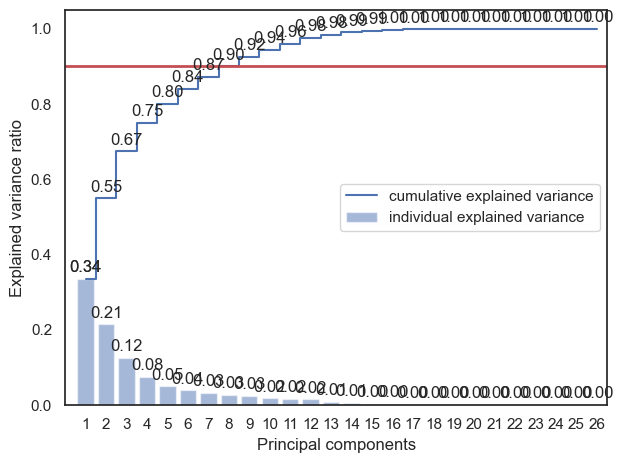

In [39]:
plt.bar(range(1,sklearn_pca.n_components_+1), sklearn_pca.explained_variance_ratio_, alpha=0.5, align='center',label='individual explained variance')
plt.step(range(1,sklearn_pca.n_components_+1), [sklearn_pca.explained_variance_ratio_[:y].sum() for y in range(1,sklearn_pca.n_components_+1)], where='mid',label='cumulative explained variance')
plt.axhline(y=0.90, linewidth=2, color = 'r')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
for i, ratio in enumerate(sklearn_pca.explained_variance_ratio_):
    plt.text(i+1, ratio + 0.01, f'{ratio:.2f}', ha='center', va='bottom')
for i, ratio in enumerate([sklearn_pca.explained_variance_ratio_[:y].sum() for y in range(1,sklearn_pca.n_components_+1)]):
    plt.text(i+1, ratio + 0.01, f'{ratio:.2f}', ha='center', va='bottom')

plt.xlim([0, sklearn_pca.n_components_+0.5])
plt.xticks(range(1, sklearn_pca.n_components_ + 1))
plt.legend(loc='best')
plt.tight_layout()

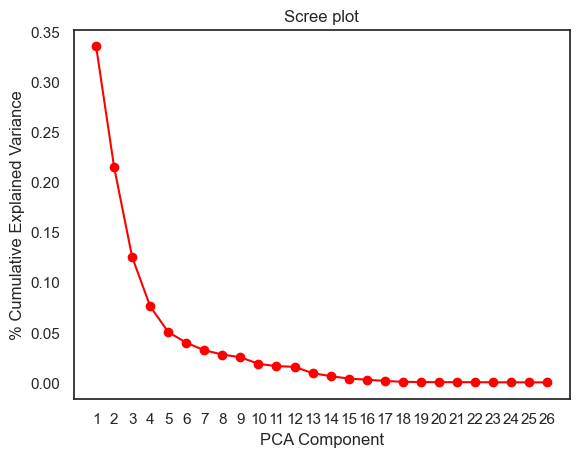

In [40]:
# Scree plot 
plt.plot(
    range(1,len(sklearn_pca.explained_variance_ratio_ )+1),
    sklearn_pca.explained_variance_ratio_,
    c='red', marker='o'
)
plt.xticks(range(1, len(sklearn_pca.explained_variance_ratio_) + 1))   
plt.xlabel('PCA Component')
plt.ylabel('% Cumulative Explained Variance')
plt.title('Scree plot')
plt.show()

In [41]:
VARIANCE_TO_KEEP = 0.85 # that would mean two componentes in our example
keep_recommend = [sklearn_pca.explained_variance_ratio_[:y].sum()>VARIANCE_TO_KEEP for y in range(1,sklearn_pca.n_components_+1)].count(False)
print("Number of components to keep to retain %s%% of the variance:" % (100*VARIANCE_TO_KEEP), keep_recommend, "out of the original", sklearn_pca.n_components_)
n_components = keep_recommend

Number of components to keep to retain 85.0% of the variance: 6 out of the original 26


In [42]:
sklearn_pca_final = PCA(n_components)
Y_sklearn = sklearn_pca_final.fit_transform(X_std)

In [43]:
# Shows Factor loadings = correlations between variables and factors
print ("")
print ("Factor loadings:")

pd.set_option('display.float_format', '{:.4f}'.format)

dfloadings=pd.DataFrame(
    data    = sklearn_pca_final.components_,
    columns = data_All.columns,
)

index_list=[]
for n in range(n_components):
    index_list.append("PC"+str(n+1))

dfloadings.index = index_list

# Hide low values so that it is clearer
dfloadings.T.where(abs(dfloadings.T) > 0.3  , "")  # we hide values lower than 0.25 to better display the relations


Factor loadings:


,PC1,PC2,PC3,PC4,PC5,PC6
SG_TOTAL_KWH_ENERGIA,,,-0.3114,,,
GI_TOTAL_KWH_ENERGIA,,,,0.3465,0.4051,
W_10uheightAboveGround_10,,,,,,-0.4213
W_10vheightAboveGround_10,,,,0.3466,,0.4085
W_2rheightAboveGround_2,,,,,,
W_2shheightAboveGround_2,,,0.3721,,,
W_2theightAboveGround_2,0.3302,,,,,
W_SUNSDsurface_0,,,,,0.3003,
W_aptmpheightAboveGround_2,0.3281,,,,,
W_dlwrfsurface_0,,,,,,


#### Communalities

In [44]:
# Communalities
commun=[]

for col in dfloadings.columns:
    commun.append((dfloadings.iloc[0:3][col]**2).sum())
    
dfcommun = pd.DataFrame(commun,index=dfloadings.columns, columns=["Communalities"])
dfcommun.sort_values("Communalities", ascending=False)

,Communalities
W_qheightAboveGround_80,0.1932
W_2shheightAboveGround_2,0.1892
W_pwatatmosphereSingleLayer_0,0.1618
W_dswrfsurface_0,0.1498
W_10uheightAboveGround_10,0.1487
W_uheightAboveGround_80,0.1434
W_2rheightAboveGround_2,0.1400
W_presheightAboveGround_80,0.1398
W_spsurface_0,0.1386
W_msletmeanSea_0,0.1309


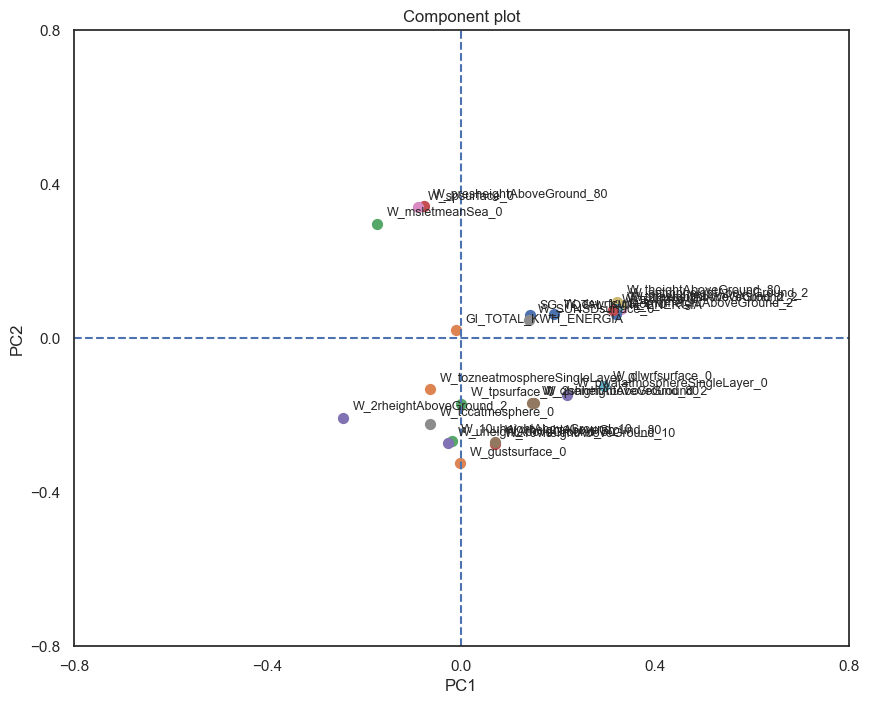

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Get the loadings of x and y axes
dfloadT = dfloadings.T

xs = dfloadT.PC1
ys = dfloadT.PC2
 
plt.figure(figsize=(10, 8))
plt.axvline(x=0, color='b', linestyle='dashed')
plt.axhline(y=0, color='b', linestyle='dashed')

# Plot the loadings on a scatterplot
for i, varnames in enumerate(dfloadings.columns):
    plt.scatter(xs.iloc[i], ys.iloc[i], s=50)
    
    # Slightly offset the text to avoid overlap
    plt.text(xs.iloc[i] + 0.02, ys.iloc[i] + 0.02, varnames, fontsize=9)

# Define the axes and show plot
xticks = np.linspace(-0.8, 0.8, num=5)
yticks = np.linspace(-0.8, 0.8, num=5)
plt.xticks(xticks)
plt.yticks(yticks)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Component plot')

# Save the plot and show it
plt.savefig('Component_plot.png', bbox_inches='tight')  # Avoid cutting parts off
plt.show()